In [3]:
# Fetch dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset", output_dir="/content/data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Path to dataset files: /kaggle/input/ag-news-classification-dataset


In [4]:
from time import time
import collections
import numpy as np

In [5]:
# -*- coding: utf-8 -*-
"""

A RNN classifier applied to AG_NEWS dataset

Download dataset:
https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset

"""

import re
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torch import nn
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# HYPER-PARAMETERS
MAX_WORDS = 50 # 25 -> 50
EPOCHS = 15
LEARNING_RATE = 1e-3
BATCH_SIZE = 1024
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
MIN_FREQ = 10

# --------------------------------------------------
# Read dataset files
# --------------------------------------------------
train_data = pd.read_csv(f'{path}/train.csv')
test_data = pd.read_csv(f'{path}/test.csv')

# --------------------------------------------------
# Simple tokenizer replacement for torchtext basic_english
# --------------------------------------------------
def tokenizer(text):
    """
    Tokenizer:
    1. Lowercases
    2. Matches only words and punctuation
    """
    text = str(text).lower()
    # keep words and punctuation as separate tokens
    return re.findall(r"\w+|[^\w\s]", text)

# --------------------------------------------------
# Build datasets
# --------------------------------------------------
train_dataset = [
    (label, f"{train_data['Title'][i]} {train_data['Description'][i]}")
    for i, label in enumerate(train_data['Class Index'])
]
test_dataset = [
    (label, f"{test_data['Title'][i]} {test_data['Description'][i]}")
    for i, label in enumerate(test_data['Class Index'])
]

target_classes = ["World", "Sports", "Business", "Sci/Tech"]

# --------------------------------------------------
# Vocab replacement for torchtext.build_vocab_from_iterator
# --------------------------------------------------
counter = Counter()
for _, text in train_dataset:   # usually build vocab from train only
    counter.update(tokenizer(text))

itos = ["<PAD>", "<UNK>"] + [tok for tok, freq in counter.items() if freq >= MIN_FREQ]
stoi = {tok: idx for idx, tok in enumerate(itos)}

PAD_IDX = stoi["<PAD>"]
UNK_IDX = stoi["<UNK>"]

def numericalize(text):
    """ Returns the value from the dictionary, else UNK. """
    return [stoi.get(tok, UNK_IDX) for tok in tokenizer(text)]

# --------------------------------------------------
# Collate function
# --------------------------------------------------
def collate_batch(batch):
    Y, X = list(zip(*batch))
    Y = torch.tensor(Y, dtype=torch.long) - 1  # labels: 1..4 -> 0..3

    X = [numericalize(text) for text in X]
    X = [
        tokens + [PAD_IDX] * (MAX_WORDS - len(tokens))
        if len(tokens) < MAX_WORDS else tokens[:MAX_WORDS]
        for tokens in X
    ]

    X = torch.tensor(X, dtype=torch.long)
    return X.to(device), Y.to(device)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)

# --------------------------------------------------
# Model
# --------------------------------------------------
class Model(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        logits = self.linear(output[:, -1, :])   # raw logits
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# --------------------------------------------------
# Train / Evaluate
# --------------------------------------------------
def EvaluateModel(model, loss_fn, val_loader):
    model.eval()
    with torch.no_grad():
        Y_actual, Y_preds, losses = [], [], []

        for X, Y in val_loader:
            logits = model(X)
            loss = loss_fn(logits, Y)
            losses.append(loss.item())

            Y_actual.append(Y)
            Y_preds.append(logits.argmax(dim=-1))

        Y_actual = torch.cat(Y_actual)
        Y_preds = torch.cat(Y_preds)

    return torch.tensor(losses).mean(), Y_actual.cpu().numpy(), Y_preds.cpu().numpy()

def TrainModel(model, loss_fn, optimizer, train_loader, epochs):
    training_times = []
    for i in range(1, epochs + 1):
        epoch_start_time = time()
        model.train()
        print('Epoch:', i)
        losses = []

        for X, Y in tqdm(train_loader):
            logits = model(X)
            loss = loss_fn(logits, Y)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epoch_end_time = time()
        epoch_time_delta = epoch_end_time - epoch_start_time
        training_times.append(epoch_time_delta)

        print("Train Loss: {:.3f}".format(torch.tensor(losses).mean()))
    return training_times

Device: cpu


In [ ]:
classifier = Model(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
print('\nModel:')
print(classifier)
print('Total parameters:', count_parameters(classifier))
print('\n')


Model:
Model(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 1974384




In [ ]:
type(classifier.embedding_layer)

torch.nn.modules.sparse.Embedding

In [ ]:
times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)


In [ ]:
training_times = []
accuracies = []

for i in range(3):

  classifier = Model(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 1974384


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:04<00:00, 25.36it/s]


Train Loss: 1.319
Epoch: 2


100%|██████████| 118/118 [00:03<00:00, 32.22it/s]


Train Loss: 0.987
Epoch: 3


...

Train Loss: 0.314
Epoch: 14


100%|██████████| 118/118 [00:03<00:00, 32.37it/s]


Train Loss: 0.300
Epoch: 15


100%|██████████| 118/118 [00:04<00:00, 27.29it/s]


Train Loss: 0.289
Mean Accuracy: 0.877
Std. Accuracy: 0.007
Mean Time: 4.097


In [ ]:
train_dataset[0:3]

[(3,
  "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."),
 (3,
  'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.'),
 (3,
  "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.")]

In [ ]:
0, f"{train_data['Title'][0]} {train_data['Description'][0]}"

(0,
 "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.")

In [ ]:
train_data['Title'][0]

'Wall St. Bears Claw Back Into the Black (Reuters)'

In [ ]:
train_data['Description'][0]

"Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."

In [ ]:
train_data.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [ ]:
# Classifier arch
print(classifier)

Model(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=4, bias=True)
)


In [ ]:
train_data.columns

Index(['Class Index', 'Title', 'Description'], dtype='object')

In [ ]:
itos[:10]

['<PAD>', '<UNK>', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the']

In [ ]:
len(itos)

19635

Build and evaluate a bidirectional RNN, 1-layer RNN.

In [ ]:
# --------------------------------------------------
# Bidirectional RNN + FNN 1-Layer
# --------------------------------------------------
class BidirectionalRNNOneLayer(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear = nn.Linear(2*hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        # print(output.shape)
        logits = self.linear(output[:, -1, :])   # raw logits
        return logits

    def rnn_hidden_size(self):
        return self.rnn.hidden_size

In [ ]:
###
training_times = []
accuracies = []

for i in range(3):

  classifier = BidirectionalRNNOneLayer(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
BidirectionalRNNOneLayer(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=128, out_features=4, bias=True)
)
Total parameters: 1985264


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:03<00:00, 30.39it/s]


Train Loss: 1.342
Epoch: 2


100%|██████████| 118/118 [00:03<00:00, 30.58it/s]


Train Loss: 1.243
Epoch: 3


...

Train Loss: 0.384
Epoch: 14


100%|██████████| 118/118 [00:03<00:00, 30.61it/s]


Train Loss: 0.359
Epoch: 15


100%|██████████| 118/118 [00:03<00:00, 32.12it/s]


Train Loss: 0.332
Mean Accuracy: 0.713
Std. Accuracy: 0.224
Mean Time: 4.073


---

In [ ]:
# --------------------------------------------------
# Bidirectional RNN + FNN 2-Layer
# --------------------------------------------------
class BidirectionalRNNTwoLayer(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.Linear(2*hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        # print(output.shape)
        logits = self.linear2(self.relu(self.linear1(output[:, -1, :])))   # raw logits
        return logits

    def rnn_hidden_size(self):
        return self.rnn.hidden_size

In [ ]:
###
training_times = []
accuracies = []

for i in range(3):

  classifier = BidirectionalRNNTwoLayer(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
BidirectionalRNNTwoLayer(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 1993264


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:04<00:00, 24.25it/s]


Train Loss: 1.321
Epoch: 2


100%|██████████| 118/118 [00:03<00:00, 30.45it/s]


Train Loss: 1.159
Epoch: 3


...

Train Loss: 1.086
Epoch: 14


100%|██████████| 118/118 [00:03<00:00, 31.74it/s]


Train Loss: 1.083
Epoch: 15


100%|██████████| 118/118 [00:03<00:00, 31.66it/s]


Train Loss: 1.053
Mean Accuracy: 0.621
Std. Accuracy: 0.173
Mean Time: 4.123


---

In [ ]:
# --------------------------------------------------
# LSTM + FNN 1-Layer (1LSTM)
# --------------------------------------------------
class LSTMOneLayer(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=False
        )
        self.linear1 = nn.modules.Linear(hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear1(output[:, -1, :])   # raw logits
        return logits

    def rnn_hidden_size(self):
        return self.rnn.hidden_size

In [ ]:
###
training_times = []
accuracies = []

for i in range(3):

  classifier = LSTMOneLayer(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
LSTMOneLayer(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True)
  (linear1): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 2006256


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:05<00:00, 23.35it/s]


Train Loss: 1.169
Epoch: 2


100%|██████████| 118/118 [00:03<00:00, 29.95it/s]


Train Loss: 0.575
Epoch: 3


...

Train Loss: 0.148
Epoch: 14


100%|██████████| 118/118 [00:04<00:00, 28.04it/s]


Train Loss: 0.139
Epoch: 15


100%|██████████| 118/118 [00:04<00:00, 26.60it/s]


Train Loss: 0.128
Mean Accuracy: 0.902
Std. Accuracy: 0.000
Mean Time: 4.291


---

In [ ]:
# --------------------------------------------------
# Bidirectional LSTM + FNN 1-Layer (1Bi-LSTM)
# --------------------------------------------------
class BidirectionalLSTMOneLayer(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.modules.Linear(2*hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear1(output[:, -1, :])   # raw logits
        return logits

In [ ]:
###
training_times = []
accuracies = []

for i in range(3):

  classifier = BidirectionalLSTMOneLayer(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
BidirectionalLSTMOneLayer(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=4, bias=True)
)
Total parameters: 2049008


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:04<00:00, 29.01it/s]


Train Loss: 1.193
Epoch: 2


100%|██████████| 118/118 [00:04<00:00, 23.90it/s]


Train Loss: 0.683
Epoch: 3


...

Train Loss: 0.146
Epoch: 14


100%|██████████| 118/118 [00:04<00:00, 25.42it/s]


Train Loss: 0.133
Epoch: 15


100%|██████████| 118/118 [00:04<00:00, 27.09it/s]


Train Loss: 0.124
Mean Accuracy: 0.900
Std. Accuracy: 0.004
Mean Time: 4.524


---

In [ ]:
# --------------------------------------------------
# Bidirectional LSTM + FNN 2-Layer (2Bi-LSTM)
# --------------------------------------------------
class BidirectionalLSTMTwoLayer(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.modules.Linear(2*hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.modules.Linear(hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear2(self.relu(self.linear1(output[:, -1, :])))   # raw logits
        return logits

In [ ]:
###
training_times = []
accuracies = []

for i in range(3):

  classifier = BidirectionalLSTMTwoLayer(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
BidirectionalLSTMTwoLayer(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 2057008


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:05<00:00, 22.81it/s]


Train Loss: 1.157
Epoch: 2


100%|██████████| 118/118 [00:04<00:00, 28.56it/s]


Train Loss: 0.649
Epoch: 3


...

Train Loss: 0.127
Epoch: 14


100%|██████████| 118/118 [00:04<00:00, 29.21it/s]


Train Loss: 0.116
Epoch: 15


100%|██████████| 118/118 [00:05<00:00, 23.31it/s]


Train Loss: 0.108
Mean Accuracy: 0.898
Std. Accuracy: 0.002
Mean Time: 4.559


---

In [ ]:
# USE CPU device - 1RNN
device = torch.device("cpu")
print(f"Device: {device}")
training_times = []
accuracies = []


classifier = Model(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
print('\nModel:')
print(classifier)
print('Total parameters:', count_parameters(classifier))
print('\n')

print(f"Iteration: {i}")
times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
training_times.append(times)
_, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

accuracy = accuracy_score(Y_actual, Y_preds)
accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")

Device: cpu

Model:
Model(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 1974384


Iteration: 2
Epoch: 1


100%|██████████| 118/118 [00:17<00:00,  6.91it/s]


Train Loss: 1.326
Epoch: 2


100%|██████████| 118/118 [00:17<00:00,  6.88it/s]


Train Loss: 1.178
Epoch: 3


...

Train Loss: 0.304
Epoch: 14


100%|██████████| 118/118 [00:17<00:00,  6.88it/s]


Train Loss: 0.295
Epoch: 15


100%|██████████| 118/118 [00:17<00:00,  6.90it/s]


Train Loss: 0.278
Mean Accuracy: 0.882
Std. Accuracy: 0.000
Mean Time: 17.081


In [ ]:
### Use CPU DEVICE - 1LSTM
training_times = []
accuracies = []

classifier = LSTMOneLayer(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
print('\nModel:')
print(classifier)
print('Total parameters:', count_parameters(classifier))
print('\n')

print(f"Iteration: {i}")
times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
training_times.append(times)
_, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

accuracy = accuracy_score(Y_actual, Y_preds)
accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
LSTMOneLayer(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True)
  (linear1): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 2006256


Iteration: 2
Epoch: 1


100%|██████████| 118/118 [00:45<00:00,  2.60it/s]


Train Loss: 1.133
Epoch: 2


100%|██████████| 118/118 [00:46<00:00,  2.54it/s]


Train Loss: 0.563
Epoch: 3


...

Train Loss: 0.141
Epoch: 14


100%|██████████| 118/118 [00:46<00:00,  2.54it/s]


Train Loss: 0.162
Epoch: 15


100%|██████████| 118/118 [00:45<00:00,  2.57it/s]


Train Loss: 0.127
Mean Accuracy: 0.902
Std. Accuracy: 0.000
Mean Time: 46.159


---

In [ ]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
def reduce_dimensions(word_embeddings, perplexity=3, nof_dims=2):

    # extract the words & their vectors, as numpy arrays
    # word_vectors = [model[w] for w in words]
    # vectors = np.asarray(word_vectors)

    # reduce using t-SNE
    tsne = TSNE(n_components=nof_dims, random_state=0, perplexity=perplexity)
    # vectors = tsne.fit_transform(vectors)
    vectors = tsne.fit_transform(np.asarray(word_embeddings))

    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals

In [ ]:
def plot_with_matplotlib(x_vals, y_vals, labels):


    plt.figure(figsize=(12, 12))
    plt.scatter(x_vals, y_vals)

    # Plug labels to points
    for i in range(len(labels)):
        plt.annotate(labels[i], (x_vals[i], y_vals[i]))

In [ ]:
abow = ["business", "career", "classroom", "company", "curriculum", "degree", "employee", "exam",
"government", "homework", "investment", "job", "learning", "lecture", "lesson", "manager",
"market", "office", "profession", "research", "salary", "school", "stock", "student", "teacher",
"technology", "training", "university"]

In [ ]:
nabow = abow + ["<UNK>"]*72

In [ ]:
len(nabow)

100

In [ ]:
classifier = Model(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
print('\nModel:')
print(classifier)
print('Total parameters:', count_parameters(classifier))
print('\n')

_ = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
_, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

accuracy = accuracy_score(Y_actual, Y_preds)
accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")


Model:
Model(
  (embedding_layer): Embedding(19635, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 1974384


Epoch: 1


100%|██████████| 118/118 [00:17<00:00,  6.71it/s]


Train Loss: 1.311
Epoch: 2


100%|██████████| 118/118 [00:17<00:00,  6.90it/s]


Train Loss: 1.154
Epoch: 3


...

Train Loss: 0.331
Epoch: 14


100%|██████████| 118/118 [00:17<00:00,  6.87it/s]


Train Loss: 0.317
Epoch: 15


100%|██████████| 118/118 [00:17<00:00,  6.81it/s]


Train Loss: 0.303
Mean Accuracy: 0.887
Std. Accuracy: 0.015


In [ ]:
word_embeddings = []
for w in abow:
  lookup_tensor = torch.tensor(numericalize(w), dtype=torch.long)[0]
  word_embeddings.append(classifier.embedding_layer(lookup_tensor).detach())

In [ ]:
len(word_embeddings)

28

In [ ]:
type(word_embeddings)

list

In [ ]:
type(word_embeddings[0])

torch.Tensor

In [ ]:
word_embeddings[0]

tensor([ 0.3574, -0.7421,  1.1176, -0.0066,  0.0146,  0.3581, -0.8834, -0.5179,
         0.8927,  0.2805, -0.0966,  1.2701, -0.2676,  0.9167, -1.4272, -1.4651,
        -0.7827, -0.9037, -1.4407,  0.9037,  1.0296,  0.8039,  0.2627,  0.1223,
         0.5165, -1.0209,  0.1880,  0.5000,  0.8954,  0.4740, -1.7970,  2.4068,
         0.4307,  1.1847,  0.0690, -0.8175,  2.0619, -0.3328,  0.7341, -0.0663,
         0.1096, -2.0765,  1.4421,  0.8189, -1.1023,  2.5147,  2.3840,  1.0503,
        -1.6981, -1.1124, -0.7241,  0.3307,  1.8574, -0.0825, -1.1926,  0.7742,
         1.4848, -0.1775, -0.7871, -1.1646, -1.4773, -0.1401,  0.9698, -0.4138,
         0.4560,  0.2626,  0.6393, -1.0367, -0.8978, -1.2642, -1.6830, -0.2686,
        -0.7094,  1.3857, -0.8099,  1.1848,  0.7061, -0.6985,  0.9253,  1.1350,
        -0.4564,  0.4857,  0.3332, -0.4581,  0.6635,  0.6827,  0.2914, -1.0659,
         0.5478, -2.2958, -1.0584, -0.4694, -0.6552, -1.6511,  1.0425, -2.1121,
         0.4107, -1.8279,  0.8061,  1.27

In [ ]:
x_vals, y_vals = reduce_dimensions(word_embeddings)

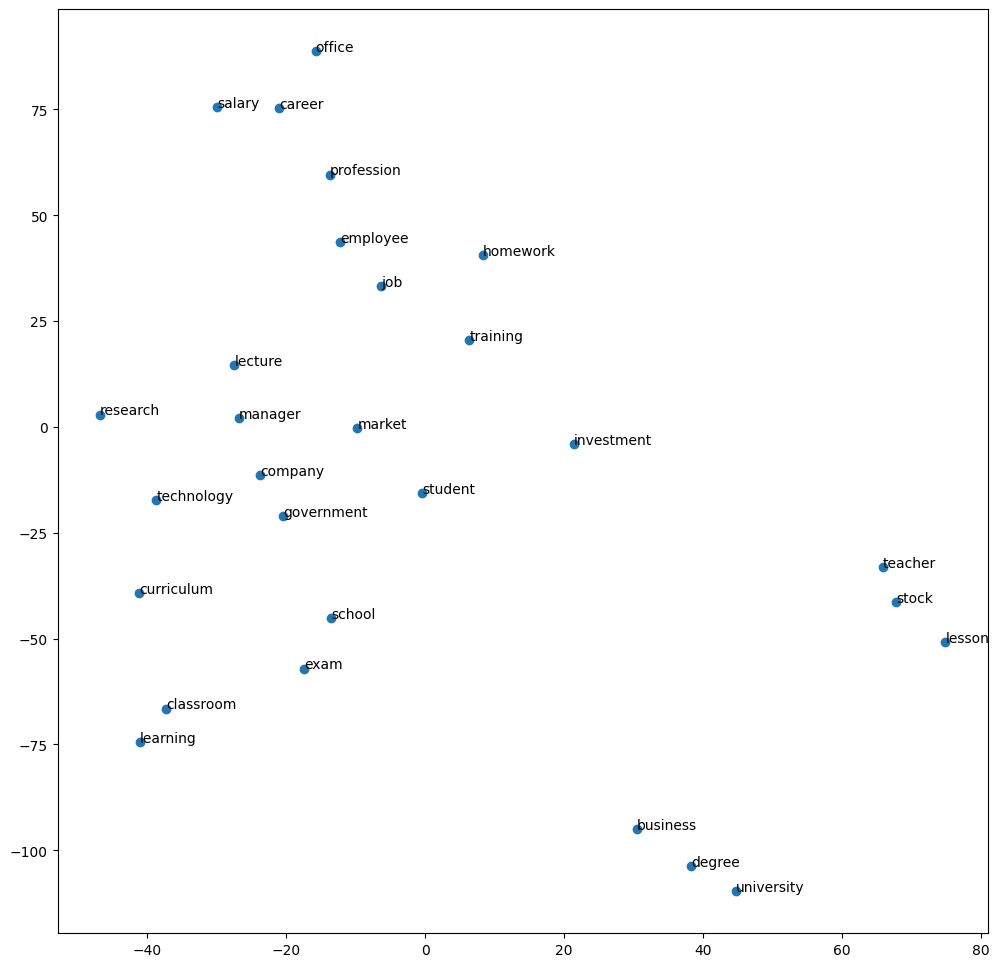

In [ ]:
plot_function = plot_with_matplotlib
# else:
#     plot_function = plot_with_plotly
plot_function(x_vals, y_vals, abow)

---

# task 5

In [2]:
!wget http://nlp.stanford.edu/data/glove.6B.zip -O /tmp/glove.6B.zip

--2026-04-26 11:23:07--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-26 11:23:07--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-26 11:23:08--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘/tmp/glove.6B.zip’


In [5]:
import os
import zipfile
with zipfile.ZipFile('/tmp/glove.6B.zip', 'r') as zip_ref:
    zip_ref.extractall('/tmp/glove')

In [10]:
word_embeddings = []
with open('/tmp/glove/glove.6B.100d.txt', "r") as f:
  for line in f.readlines():
    np_array = np.array(line.split()[1:])
    word_embeddings.append( np_array.astype("float32") )


In [11]:
word_embeddings_np = np.array(word_embeddings)

In [12]:
word_embeddings_tens = torch.tensor(word_embeddings_np)

In [16]:
dic_size = word_embeddings_tens.shape[0] # Dic size
embedding_dim = word_embeddings_tens.shape[1]  # Emb size

In [18]:
glove_embedding = nn.Embedding(
    num_embeddings=dic_size, # Dictionary size
    embedding_dim=embedding_dim, # Embedding output
).from_pretrained(word_embeddings_tens)

In [19]:
glove_embedding.weight.data[0] == word_embeddings_tens[0]

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])

In [20]:
# -*- coding: utf-8 -*-
"""

A RNN classifier applied to AG_NEWS dataset

Download dataset:
https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset

"""

import re
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torch import nn
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# HYPER-PARAMETERS
MAX_WORDS = 25
EPOCHS = 15
LEARNING_RATE = 1e-3
BATCH_SIZE = 1024
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
MIN_FREQ = 10

# --------------------------------------------------
# Read dataset files
# --------------------------------------------------
train_data = pd.read_csv(f'{path}/train.csv')
test_data = pd.read_csv(f'{path}/test.csv')

# --------------------------------------------------
# Simple tokenizer replacement for torchtext basic_english
# --------------------------------------------------
def tokenizer(text):
    """
    Tokenizer:
    1. Lowercases
    2. Matches only words and punctuation
    """
    text = str(text).lower()
    # keep words and punctuation as separate tokens
    return re.findall(r"\w+|[^\w\s]", text)

# --------------------------------------------------
# Build datasets
# --------------------------------------------------
train_dataset = [
    (label, f"{train_data['Title'][i]} {train_data['Description'][i]}")
    for i, label in enumerate(train_data['Class Index'])
]
test_dataset = [
    (label, f"{test_data['Title'][i]} {test_data['Description'][i]}")
    for i, label in enumerate(test_data['Class Index'])
]

target_classes = ["World", "Sports", "Business", "Sci/Tech"]

# --------------------------------------------------
# Vocab replacement for torchtext.build_vocab_from_iterator
# --------------------------------------------------
counter = Counter()
for _, text in train_dataset:   # usually build vocab from train only
    counter.update(tokenizer(text))

itos = ["<PAD>", "<UNK>"] + [tok for tok, freq in counter.items() if freq >= MIN_FREQ]
stoi = {tok: idx for idx, tok in enumerate(itos)}

PAD_IDX = stoi["<PAD>"]
UNK_IDX = stoi["<UNK>"]

def numericalize(text):
    """ Returns the value from the dictionary, else UNK. """
    return [stoi.get(tok, UNK_IDX) for tok in tokenizer(text)]

# --------------------------------------------------
# Collate function
# --------------------------------------------------
def collate_batch(batch):
    Y, X = list(zip(*batch))
    Y = torch.tensor(Y, dtype=torch.long) - 1  # labels: 1..4 -> 0..3

    X = [numericalize(text) for text in X]
    X = [
        tokens + [PAD_IDX] * (MAX_WORDS - len(tokens))
        if len(tokens) < MAX_WORDS else tokens[:MAX_WORDS]
        for tokens in X
    ]

    X = torch.tensor(X, dtype=torch.long)
    return X.to(device), Y.to(device)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)

Device: cuda


In [21]:
# --------------------------------------------------
# Model
# --------------------------------------------------
class Model1RNN(nn.Module):
    def __init__(self, word_embeddings_tensor, dic_size, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=dic_size, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        ).from_pretrained(word_embeddings_tensor, freeze=False)

        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        logits = self.linear(output[:, -1, :])   # raw logits
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# --------------------------------------------------
# Train / Evaluate
# --------------------------------------------------
def EvaluateModel(model, loss_fn, val_loader):
    model.eval()
    with torch.no_grad():
        Y_actual, Y_preds, losses = [], [], []

        for X, Y in val_loader:
            logits = model(X)
            loss = loss_fn(logits, Y)
            losses.append(loss.item())

            Y_actual.append(Y)
            Y_preds.append(logits.argmax(dim=-1))

        Y_actual = torch.cat(Y_actual)
        Y_preds = torch.cat(Y_preds)

    return torch.tensor(losses).mean(), Y_actual.cpu().numpy(), Y_preds.cpu().numpy()

def TrainModel(model, loss_fn, optimizer, train_loader, epochs):
    training_times = []
    for i in range(1, epochs + 1):
        epoch_start_time = time()
        model.train()
        print('Epoch:', i)
        losses = []

        for X, Y in tqdm(train_loader):
            logits = model(X)
            loss = loss_fn(logits, Y)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epoch_end_time = time()
        epoch_time_delta = epoch_end_time - epoch_start_time
        training_times.append(epoch_time_delta)

        print("Train Loss: {:.3f}".format(torch.tensor(losses).mean()))
    return training_times

In [22]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1RNN(word_embeddings_tens, dic_size, embedding_dim, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1RNN(
  (embedding_layer): Embedding(400000, 100)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 40010884


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:05<00:00, 21.95it/s]


Train Loss: 1.151
Epoch: 2


100%|██████████| 118/118 [00:03<00:00, 34.04it/s]


Train Loss: 0.640
Epoch: 3


...

Train Loss: 0.153
Epoch: 14


100%|██████████| 118/118 [00:04<00:00, 25.66it/s]


Train Loss: 0.146
Epoch: 15


100%|██████████| 118/118 [00:03<00:00, 34.13it/s]


Train Loss: 0.145
Mean Accuracy: 0.883
Std. Accuracy: 0.003
Mean Time: 4.398


# 1Bi-RNN

In [23]:
# --------------------------------------------------
# Model - 1Bi-RNN
# --------------------------------------------------
class Model1Bi_RNN(nn.Module):
    def __init__(self, word_embeddings_tensor, dic_size, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=dic_size, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        ).from_pretrained(word_embeddings_tensor, freeze=False)

        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear = nn.Linear(2*hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        logits = self.linear(output[:, -1, :])   # raw logits
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [24]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1Bi_RNN(word_embeddings_tens, dic_size, embedding_dim, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1Bi_RNN(
  (embedding_layer): Embedding(400000, 100)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=128, out_features=4, bias=True)
)
Total parameters: 40021764


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:03<00:00, 34.51it/s]


Train Loss: 1.148
Epoch: 2


100%|██████████| 118/118 [00:04<00:00, 24.99it/s]


Train Loss: 0.652
Epoch: 3


...

Train Loss: 0.131
Epoch: 14


100%|██████████| 118/118 [00:04<00:00, 26.14it/s]


Train Loss: 0.126
Epoch: 15


100%|██████████| 118/118 [00:03<00:00, 33.95it/s]


Train Loss: 0.120
Mean Accuracy: 0.880
Std. Accuracy: 0.007
Mean Time: 3.841


# 2Bi-RNN

In [25]:
# --------------------------------------------------
# Bidirectional RNN + FNN 2-Layer
# --------------------------------------------------
class Model2Bi_RNN(nn.Module):
    def __init__(self, word_embeddings_tensor, dic_size, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=dic_size, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        ).from_pretrained(word_embeddings_tensor, freeze=False)

        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.linear1 = nn.Linear(2*hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        # print(output.shape)
        logits = self.linear2(self.relu(self.linear1(output[:, -1, :])))   # raw logits
        return logits

    def rnn_hidden_size(self):
        return self.rnn.hidden_size

In [26]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model2Bi_RNN(word_embeddings_tens, dic_size, embedding_dim, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model2Bi_RNN(
  (embedding_layer): Embedding(400000, 100)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 40029764


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:03<00:00, 31.36it/s]


Train Loss: 1.165
Epoch: 2


100%|██████████| 118/118 [00:04<00:00, 25.73it/s]


Train Loss: 0.629
Epoch: 3


...

Train Loss: 0.169
Epoch: 14


100%|██████████| 118/118 [00:03<00:00, 31.75it/s]


Train Loss: 0.159
Epoch: 15


100%|██████████| 118/118 [00:03<00:00, 34.39it/s]


Train Loss: 0.155
Mean Accuracy: 0.881
Std. Accuracy: 0.003
Mean Time: 3.888


# 1LSTM

In [27]:
# --------------------------------------------------
# LSTM + FNN 1-Layer (1LSTM)
# --------------------------------------------------
class Model1LSTM(nn.Module):
    def __init__(self, word_embeddings_tensor, dic_size, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=dic_size, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        ).from_pretrained(word_embeddings_tensor, freeze=False)

        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=False
        )
        self.linear1 = nn.modules.Linear(hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear1(output[:, -1, :])   # raw logits
        return logits

    def rnn_hidden_size(self):
        return self.rnn.hidden_size

In [28]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1LSTM(word_embeddings_tens, dic_size, embedding_dim, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1LSTM(
  (embedding_layer): Embedding(400000, 100)
  (lstm): LSTM(100, 64, batch_first=True)
  (linear1): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 40042756


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:04<00:00, 28.04it/s]


Train Loss: 0.991
Epoch: 2


100%|██████████| 118/118 [00:04<00:00, 26.93it/s]


Train Loss: 0.424
Epoch: 3


...

Train Loss: 0.096
Epoch: 14


100%|██████████| 118/118 [00:03<00:00, 31.69it/s]


Train Loss: 0.091
Epoch: 15


100%|██████████| 118/118 [00:04<00:00, 28.93it/s]


Train Loss: 0.088
Mean Accuracy: 0.886
Std. Accuracy: 0.004
Mean Time: 3.963


# 1Bi-LSTM

In [29]:
# --------------------------------------------------
# Bidirectional LSTM + FNN 1-Layer (1Bi-LSTM)
# --------------------------------------------------
class Model1Bi_LSTM(nn.Module):
    def __init__(self, word_embeddings_tensor, dic_size, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=dic_size, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        ).from_pretrained(word_embeddings_tensor, freeze=False)

        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.modules.Linear(2*hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear1(output[:, -1, :])   # raw logits
        return logits

In [30]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1Bi_LSTM(word_embeddings_tens, dic_size, embedding_dim, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1Bi_LSTM(
  (embedding_layer): Embedding(400000, 100)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=4, bias=True)
)
Total parameters: 40085508


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:04<00:00, 29.40it/s]


Train Loss: 1.023
Epoch: 2


100%|██████████| 118/118 [00:03<00:00, 30.92it/s]


Train Loss: 0.419
Epoch: 3


...

Train Loss: 0.099
Epoch: 14


100%|██████████| 118/118 [00:04<00:00, 25.79it/s]


Train Loss: 0.092
Epoch: 15


100%|██████████| 118/118 [00:04<00:00, 28.83it/s]


Train Loss: 0.086
Mean Accuracy: 0.888
Std. Accuracy: 0.000
Mean Time: 4.245


# 2Bi-LSTM

In [31]:
# --------------------------------------------------
# Bidirectional LSTM + FNN 2-Layer (2Bi-LSTM)
# --------------------------------------------------
class Model2Bi_LSTM(nn.Module):
    def __init__(self, word_embeddings_tensor, dic_size, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=dic_size, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        ).from_pretrained(word_embeddings_tensor, freeze=False)

        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.modules.Linear(2*hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.modules.Linear(hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear2(self.relu(self.linear1(output[:, -1, :])))   # raw logits
        return logits

In [32]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model2Bi_LSTM(word_embeddings_tens, dic_size, embedding_dim, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model2Bi_LSTM(
  (embedding_layer): Embedding(400000, 100)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters: 40093508


Iteration: 0
Epoch: 1


100%|██████████| 118/118 [00:04<00:00, 29.11it/s]


Train Loss: 1.018
Epoch: 2


100%|██████████| 118/118 [00:04<00:00, 23.77it/s]


Train Loss: 0.496
Epoch: 3


...

Train Loss: 0.089
Epoch: 14


100%|██████████| 118/118 [00:04<00:00, 28.58it/s]


Train Loss: 0.081
Epoch: 15


100%|██████████| 118/118 [00:03<00:00, 31.34it/s]


Train Loss: 0.073
Mean Accuracy: 0.888
Std. Accuracy: 0.004
Mean Time: 4.218


---
# Task 7


In [9]:
# Fetch dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews", output_dir="/content/data2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [36]:
!pip install scikit-learn

In [10]:
from sklearn.model_selection import train_test_split

In [35]:
# -*- coding: utf-8 -*-
"""

A RNN classifier applied to AG_NEWS dataset

Download dataset:
https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset

"""

import re
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torch import nn
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# HYPER-PARAMETERS
MAX_WORDS = 25 # 25 -> 50
EPOCHS = 15
LEARNING_RATE = 1e-3
BATCH_SIZE = 1024
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
MIN_FREQ = 10

# --------------------------------------------------
# Read dataset files
# --------------------------------------------------
dataset = pd.read_csv(f"{path}/IMDB Dataset.csv")

X = dataset["review"]
y = dataset["sentiment"]


Device: cpu


In [36]:
print("Category Mapping:", dict(enumerate(y.astype("category").cat.categories)))

Category Mapping: {0: 'negative', 1: 'positive'}


In [37]:
# Convert sentiment to int
y = y.astype("category").cat.codes

In [39]:
# Sanity check
y.head()

,0
0,1
1,1
2,1
3,0
4,1


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [42]:
X_train[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [43]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000,), (10000,), (40000,), (10000,))

In [73]:
# --------------------------------------------------
# Simple tokenizer replacement for torchtext basic_english
# --------------------------------------------------
def tokenizer(text):
    """
    Tokenizer:
    1. Lowercases
    2. Matches only words and punctuation
    """
    text = str(text).lower()
    # keep words and punctuation as separate tokens
    return re.findall(r"\w+|[^\w\s]", text)

# --------------------------------------------------
# Build datasets
# --------------------------------------------------
train_dataset = [
    (sentiment, review)
    for sentiment, review in zip(y_train, X_train)
]

test_dataset = [
    (sentiment, review)
    for sentiment, review in zip(y_test, X_test)
]

target_classes = ["negative", "positive"]


In [51]:
train_dataset[0]

(1,
 'This was the first "Walking Tall" movie I saw, I think in a $2 movie theater along Hollywood Blvd. , so I didn\'t have any reference to the first installment done by Joe Don Baker. I remember being shocked at the corrupted system of McNairy County and the brutality of the "redneck gangs". I was also amazed at the fact that one man decided he\'s not going to let it slide, and went out to do something about it. Courageous ? I thought so - to a point where it sent shivers up my spine.<br /><br />I think this movie is a great story about American courage to stand up and do something about a system that\'s only serving its own interest. I was pretty blown away about it, and think this is still one of the best movie of the hero/anti-hero genre, which one might laugh but includes recent movies like the "The Punisher", but even more so because it\'s a true story. The recent remake starring the "Rock" just doesn\'t do any justice to the real fire in the story of Buford Pusser.<br /><br />

In [74]:
# --------------------------------------------------
# Vocab replacement for torchtext.build_vocab_from_iterator
# --------------------------------------------------
counter = Counter()
for _, text in train_dataset:   # usually build vocab from train only
    counter.update(tokenizer(text))

itos = ["<PAD>", "<UNK>"] + [tok for tok, freq in counter.items() if freq >= MIN_FREQ]
stoi = {tok: idx for idx, tok in enumerate(itos)}

PAD_IDX = stoi["<PAD>"]
UNK_IDX = stoi["<UNK>"]

def numericalize(text):
    """ Returns the value from the dictionary, else UNK. """
    return [stoi.get(tok, UNK_IDX) for tok in tokenizer(text)]

# --------------------------------------------------
# Collate function
# --------------------------------------------------
def collate_batch(batch):
    Y, X = list(zip(*batch))
    Y = torch.tensor(Y, dtype=torch.long)

    X = [numericalize(text) for text in X]
    X = [
        tokens + [PAD_IDX] * (MAX_WORDS - len(tokens))
        if len(tokens) < MAX_WORDS else tokens[:MAX_WORDS]
        for tokens in X
    ]

    X = torch.tensor(X, dtype=torch.long)
    return X.to(device), Y.to(device)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)

In [75]:
# --------------------------------------------------
# Model
# --------------------------------------------------
class Model1RNN(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        logits = self.linear(output[:, -1, :])   # raw logits
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# --------------------------------------------------
# Train / Evaluate
# --------------------------------------------------
def EvaluateModel(model, loss_fn, val_loader):
    model.eval()
    with torch.no_grad():
        Y_actual, Y_preds, losses = [], [], []

        for X, Y in val_loader:
            logits = model(X)
            loss = loss_fn(logits, Y)
            losses.append(loss.item())

            Y_actual.append(Y)
            Y_preds.append(logits.argmax(dim=-1))

        Y_actual = torch.cat(Y_actual)
        Y_preds = torch.cat(Y_preds)

    return torch.tensor(losses).mean(), Y_actual.cpu().numpy(), Y_preds.cpu().numpy()

def TrainModel(model, loss_fn, optimizer, train_loader, epochs):
    training_times = []
    for i in range(1, epochs + 1):
        epoch_start_time = time()
        model.train()
        print('Epoch:', i)
        losses = []

        for X, Y in tqdm(train_loader):
            logits = model(X)
            loss = loss_fn(logits, Y)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epoch_end_time = time()
        epoch_time_delta = epoch_end_time - epoch_start_time
        training_times.append(epoch_time_delta)

        print("Train Loss: {:.3f}".format(torch.tensor(losses).mean()))
    return training_times

In [76]:
classifier = Model1RNN(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
classifier

Model1RNN(
  (embedding_layer): Embedding(25498, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=2, bias=True)
)

## 1RNN

In [78]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1RNN(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1RNN(
  (embedding_layer): Embedding(25498, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=2, bias=True)
)
Total parameters: 2560554


Iteration: 0
Epoch: 1


100%|██████████| 40/40 [00:13<00:00,  2.91it/s]


Train Loss: 0.699
Epoch: 2


100%|██████████| 40/40 [00:10<00:00,  3.80it/s]


Train Loss: 0.688
Epoch: 3


...

Train Loss: 0.359
Epoch: 14


100%|██████████| 40/40 [00:09<00:00,  4.22it/s]


Train Loss: 0.342
Epoch: 15


100%|██████████| 40/40 [00:10<00:00,  3.74it/s]


Train Loss: 0.315
Mean Accuracy: 0.721
Std. Accuracy: 0.005
Mean Time: 11.724


## 1Bi-RNN

In [81]:
class Model1Bi_RNN(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear = nn.Linear(2*hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        # print(output.shape)
        logits = self.linear(output[:, -1, :])   # raw logits
        return logits

In [82]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1Bi_RNN(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1Bi_RNN(
  (embedding_layer): Embedding(25498, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=128, out_features=2, bias=True)
)
Total parameters: 2571306


Iteration: 0
Epoch: 1


100%|██████████| 40/40 [00:38<00:00,  1.05it/s]


Train Loss: 0.698
Epoch: 2


100%|██████████| 40/40 [00:25<00:00,  1.56it/s]


Train Loss: 0.688
Epoch: 3


...

Train Loss: 0.364
Epoch: 14


100%|██████████| 40/40 [00:12<00:00,  3.14it/s]


Train Loss: 0.341
Epoch: 15


100%|██████████| 40/40 [00:12<00:00,  3.12it/s]


Train Loss: 0.322
Mean Accuracy: 0.717
Std. Accuracy: 0.004
Mean Time: 14.980


## 2Bi-RNN

In [83]:
# --------------------------------------------------
# Bidirectional RNN + FNN 2-Layer
# --------------------------------------------------
class Model2Bi_RNN(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.rnn = nn.RNN(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.Linear(2*hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(embeddings)
        # print(output.shape)
        logits = self.linear2(self.relu(self.linear1(output[:, -1, :])))   # raw logits
        return logits

In [84]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model2Bi_RNN(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model2Bi_RNN(
  (embedding_layer): Embedding(25498, 100, padding_idx=0)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=64, out_features=2, bias=True)
)
Total parameters: 2579434


Iteration: 0
Epoch: 1


100%|██████████| 40/40 [00:12<00:00,  3.10it/s]


Train Loss: 0.693
Epoch: 2


100%|██████████| 40/40 [00:12<00:00,  3.09it/s]


Train Loss: 0.687
Epoch: 3


...

Train Loss: 0.348
Epoch: 14


100%|██████████| 40/40 [00:13<00:00,  3.02it/s]


Train Loss: 0.325
Epoch: 15


100%|██████████| 40/40 [00:13<00:00,  3.07it/s]


Train Loss: 0.307
Mean Accuracy: 0.709
Std. Accuracy: 0.005
Mean Time: 13.107


## 1LSTM

In [85]:
# --------------------------------------------------
# LSTM + FNN 1-Layer (1LSTM)
# --------------------------------------------------
class Model1LSTM(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=False
        )
        self.linear1 = nn.modules.Linear(hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear1(output[:, -1, :])   # raw logits
        return logits

    def rnn_hidden_size(self):
        return self.rnn.hidden_size

In [86]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1LSTM(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1LSTM(
  (embedding_layer): Embedding(25498, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True)
  (linear1): Linear(in_features=64, out_features=2, bias=True)
)
Total parameters: 2592426


Iteration: 0
Epoch: 1


100%|██████████| 40/40 [00:19<00:00,  2.08it/s]


Train Loss: 0.691
Epoch: 2


100%|██████████| 40/40 [00:17<00:00,  2.25it/s]


Train Loss: 0.675
Epoch: 3


...

Train Loss: 0.278
Epoch: 14


100%|██████████| 40/40 [00:17<00:00,  2.25it/s]


Train Loss: 0.245
Epoch: 15


100%|██████████| 40/40 [00:18<00:00,  2.15it/s]


Train Loss: 0.222
Mean Accuracy: 0.715
Std. Accuracy: 0.004
Mean Time: 18.216


## 1Bi-LSTM

In [87]:
# --------------------------------------------------
# Bidirectional LSTM + FNN 1-Layer (1Bi-LSTM)
# --------------------------------------------------
class Model1Bi_LSTM(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.modules.Linear(2*hidden_dim, output_dim)


    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear1(output[:, -1, :])   # raw logits
        return logits

In [88]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1Bi_LSTM(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1Bi_LSTM(
  (embedding_layer): Embedding(25498, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=2, bias=True)
)
Total parameters: 2635050


Iteration: 0
Epoch: 1


100%|██████████| 40/40 [00:29<00:00,  1.35it/s]


Train Loss: 0.692
Epoch: 2


100%|██████████| 40/40 [00:30<00:00,  1.32it/s]


Train Loss: 0.673
Epoch: 3


...

Train Loss: 0.278
Epoch: 14


100%|██████████| 40/40 [00:29<00:00,  1.37it/s]


Train Loss: 0.256
Epoch: 15


100%|██████████| 40/40 [00:29<00:00,  1.33it/s]


Train Loss: 0.242
Mean Accuracy: 0.715
Std. Accuracy: 0.005
Mean Time: 29.737


## 2Bi-LSTM

In [89]:
# --------------------------------------------------
# Bidirectional LSTM + FNN 2-Layer (2Bi-LSTM)
# --------------------------------------------------
class Model2Bi_LSTM(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=input_dim, # Dictionary size
            embedding_dim=embedding_dim, # Embedding output
            padding_idx=pad_idx
        )
        self.lstm = nn.modules.rnn.LSTM(
            input_size=embedding_dim, # RNN input from embeding layer
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.linear1 = nn.modules.Linear(2*hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.modules.Linear(hidden_dim, output_dim)

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.lstm(embeddings)
        # print(output.shape)
        logits = self.linear2(self.relu(self.linear1(output[:, -1, :])))   # raw logits
        return logits

In [90]:
training_times = []
accuracies = []

for i in range(3):
  classifier = Model1Bi_LSTM(len(itos), EMBEDDING_DIM, HIDDEN_DIM, len(target_classes), PAD_IDX).to(device)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
  print('\nModel:')
  print(classifier)
  print('Total parameters:', count_parameters(classifier))
  print('\n')

  print(f"Iteration: {i}")
  times = TrainModel(classifier, loss_fn, optimizer, train_loader, EPOCHS)
  training_times.append(times)
  _, Y_actual, Y_preds = EvaluateModel(classifier, loss_fn, test_loader)

  accuracy = accuracy_score(Y_actual, Y_preds)
  accuracies.append(accuracy)

print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"Std. Accuracy: {np.std(accuracies):.3f}")
print(f"Mean Time: {np.mean(training_times):.3f}")


Model:
Model1Bi_LSTM(
  (embedding_layer): Embedding(25498, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (linear1): Linear(in_features=128, out_features=2, bias=True)
)
Total parameters: 2635050


Iteration: 0
Epoch: 1


100%|██████████| 40/40 [00:30<00:00,  1.32it/s]


Train Loss: 0.691
Epoch: 2


100%|██████████| 40/40 [00:30<00:00,  1.30it/s]


Train Loss: 0.669
Epoch: 3


...

Train Loss: 0.273
Epoch: 14


100%|██████████| 40/40 [00:30<00:00,  1.31it/s]


Train Loss: 0.251
Epoch: 15


100%|██████████| 40/40 [00:31<00:00,  1.27it/s]


Train Loss: 0.220
Mean Accuracy: 0.712
Std. Accuracy: 0.005
Mean Time: 29.698
